In [6]:
"Importações necessárias"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [7]:
"Carregar os dados"

movies = pd.read_csv('../data/ml-25m/movies.csv')
ratings = pd.read_csv('../data/ml-25m/ratings.csv')

print(f"Filmes: {movies.shape}")
print(f"Avaliações: {ratings.shape}")

Filmes: (62423, 3)
Avaliações: (25000095, 4)


In [8]:
"Visualizar filmes"

movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [9]:
"Visualizar avaliações"

ratings.head(10)

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
5,1,1088,4.0,1147868495
6,1,1175,3.5,1147868826
7,1,1217,3.5,1147878326
8,1,1237,5.0,1147868839
9,1,1250,4.0,1147868414


In [10]:
"Estatísticas Gerais:"

print("=== RATINGS ===")
print(f"Total de avaliações: {len(ratings):,}")
print(f"Total de usuários únicos: {ratings['userId'].nunique():,}")
print(f"Total de filmes avaliados: {ratings['movieId'].nunique():,}")
print(f"\nNota mínima: {ratings['rating'].min()}")
print(f"Nota máxima: {ratings['rating'].max()}")
print(f"Nota média: {ratings['rating'].mean():.2f}")

=== RATINGS ===
Total de avaliações: 25,000,095
Total de usuários únicos: 162,541
Total de filmes avaliados: 59,047

Nota mínima: 0.5
Nota máxima: 5.0
Nota média: 3.53


In [12]:
"Filmes mais avaliados:"

top_filmes = (ratings.groupby('movieId')['rating']
              .count()
              .reset_index()
              .rename(columns={'rating': 'total_avaliacoes'})
              .merge(movies[['movieId', 'title']], on='movieId')
              .sort_values('total_avaliacoes', ascending=False)
              .head(10))

top_filmes[['title', 'total_avaliacoes']]

,title,total_avaliacoes
351,Forrest Gump (1994),81491
314,"Shawshank Redemption, The (1994)",81482
292,Pulp Fiction (1994),79672
585,"Silence of the Lambs, The (1991)",74127
2480,"Matrix, The (1999)",72674
257,Star Wars: Episode IV - A New Hope (1977),68717
475,Jurassic Park (1993),64144
522,Schindler's List (1993),60411
108,Braveheart (1995),59184
2867,Fight Club (1999),58773


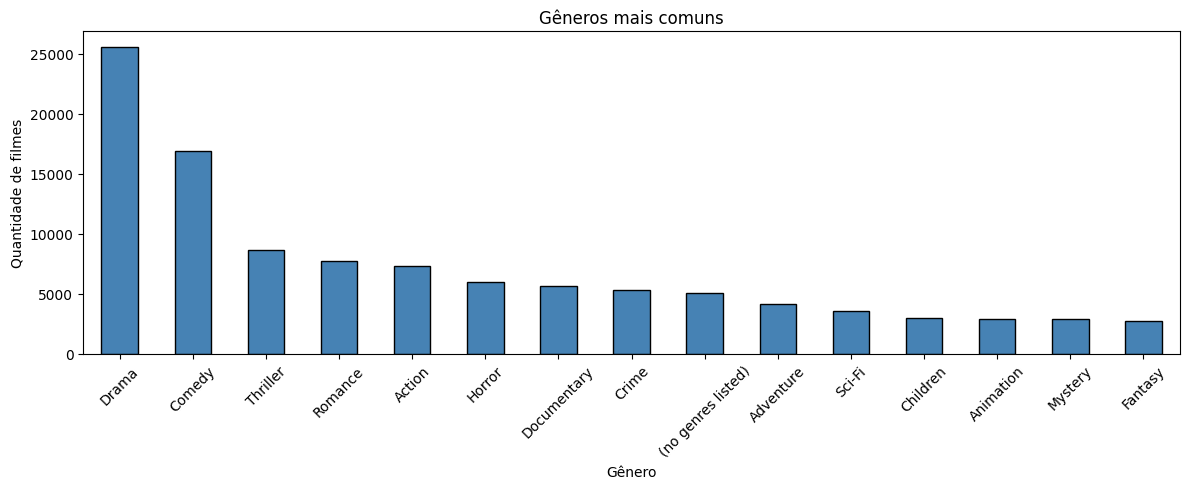

In [13]:
"Gêneros mais comuns:"

generos = movies['genres'].str.split('|').explode()
generos_count = generos.value_counts().head(15)

plt.figure(figsize=(12, 5))
generos_count.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Gêneros mais comuns')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de filmes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Média de avaliações por usuário: 154
Mediana de avaliações por usuário: 71
Usuário mais ativo: 32,202 avaliações


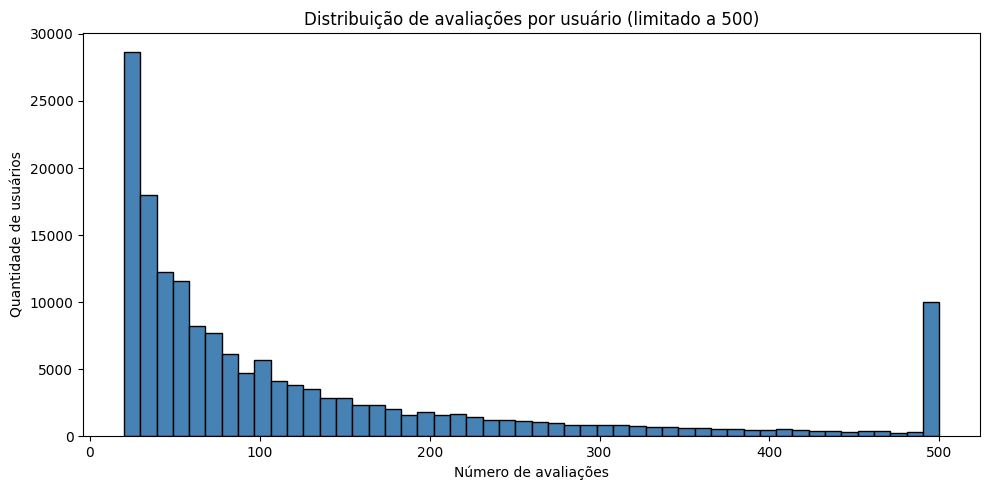

In [14]:
"Usuários mais ativos:"

avaliacoes_por_usuario = ratings.groupby('userId')['rating'].count()

print(f"Média de avaliações por usuário: {avaliacoes_por_usuario.mean():.0f}")
print(f"Mediana de avaliações por usuário: {avaliacoes_por_usuario.median():.0f}")
print(f"Usuário mais ativo: {avaliacoes_por_usuario.max():,} avaliações")

plt.figure(figsize=(10, 5))
avaliacoes_por_usuario.clip(upper=500).plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribuição de avaliações por usuário (limitado a 500)')
plt.xlabel('Número de avaliações')
plt.ylabel('Quantidade de usuários')
plt.tight_layout()
plt.show()